<a href="https://colab.research.google.com/github/kamilczynski/ZajeciaYOLO/blob/main/maliny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.6/914.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load a model
model = YOLO("yolo11s.pt")

100%|██████████| 18.4M/18.4M [00:00<00:00, 69.3MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/dataset2

images	labels


In [ ]:
# Tworzymy plik data.yaml
data_yaml = """
path: /content/drive/MyDrive/dataset2
train: images/train
val: images/valid
test: images/test


names:
  0: 'cane'
"""

with open('data.yaml', 'w') as f:
    f.write(data_yaml)

print("Plik data.yaml utworzony!")

Plik data.yaml utworzony!


In [ ]:
from ultralytics import YOLO

# Wczytaj pretrenowany model YOLOv11
model = YOLO("yolo11s.pt")

# Uruchom trening z dostosowanymi parametrami
results = model.train(
    data="data.yaml",         # Ścieżka do pliku YAML
    epochs=5,                # Liczba epok
    batch=16,                 # Zwiększony batch size (przy odpowiednim GPU)
    imgsz=640,                # Rozdzielczość obrazów
    project="runs/train",     # Gdzie zapisać wyniki treningu
    name="cane",     # Nazwa treningu
    lr0=0.001,                # Początkowa wartość learning rate
    patience=5,               # Wczesne zatrzymanie, jeśli nie ma poprawy
    augment=True,             # Zaawansowana augmentacja danych
    workers=2                 # Liczba wątków do przetwarzania danych
)

Ultralytics 8.3.73 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=data.yaml, epochs=5, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs/train, name=cane, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=N

100%|██████████| 755k/755k [00:00<00:00, 6.07MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

train: Scanning /content/drive/MyDrive/dataset2/labels/train... 182 images, 0 backgrounds, 0 corrupt: 100%|██████████| 182/182 [01:18<00:00,  2.32it/s]

train: New cache created: /content/drive/MyDrive/dataset2/labels/train.cache


...

        5/5         0G       2.47      1.862      1.491         84        640: 100%|██████████| 12/12 [06:23<00:00, 31.98s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:21<00:00, 10.56s/it]

                   all         41        361      0.202      0.342       0.16     0.0355



5 epochs completed in 0.586 hours.
Optimizer stripped from runs/train/cane/weights/last.pt, 19.2MB
Optimizer stripped from runs/train/cane/weights/best.pt, 19.2MB

Validating runs/train/cane/weights/best.pt...
Ultralytics 8.3.73 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:46<00:00, 23.39s/it]


                   all         41        361      0.353      0.476       0.32     0.0887
Speed: 2.2ms preprocess, 1033.9ms inference, 0.0ms loss, 80.8ms postprocess per image
Results saved to runs/train/cane



image 1/1 /content/drive/My Drive/dataset2/images/valid/DJI_20250109135325_0150_D.JPG: 480x640 3 canes, 343.7ms
Speed: 2.7ms preprocess, 343.7ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


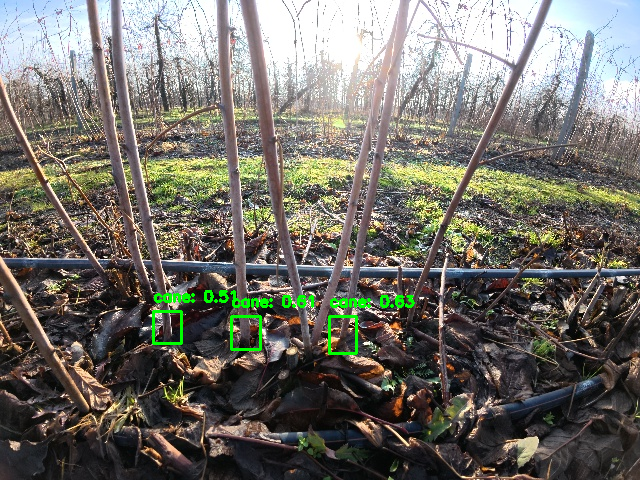

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Wczytaj wytrenowany model
model = YOLO("runs/train/cane/weights/best.pt")

# Funkcja do predykcji i wyświetlenia obrazu
def detect_and_show(image_path):
    # Wykonaj predykcję
    results = model.predict(source=image_path, conf=0.5)  # Próg pewności

    # Wczytaj oryginalny obraz
    image = cv2.imread(image_path)

    # Rysuj wyniki na obrazie
    for result in results[0].boxes:
        x1, y1, x2, y2 = map(int, result.xyxy[0].tolist())  # Współrzędne prostokąta
        conf = result.conf[0]  # Pewność
        cls = result.cls[0]  # Klasa

        # Rysowanie prostokąta na obrazie
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Tekst (klasa + pewność)
        text = f"{model.names[int(cls)]}: {conf:.2f}"
        cv2.putText(image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Wyświetl obraz w Colab
    cv2_imshow(image)

# Wskaż ścieżkę do obrazu
image_path = "/content/drive/My Drive/dataset2/images/valid/DJI_20250109135325_0150_D.JPG"
detect_and_show(image_path)

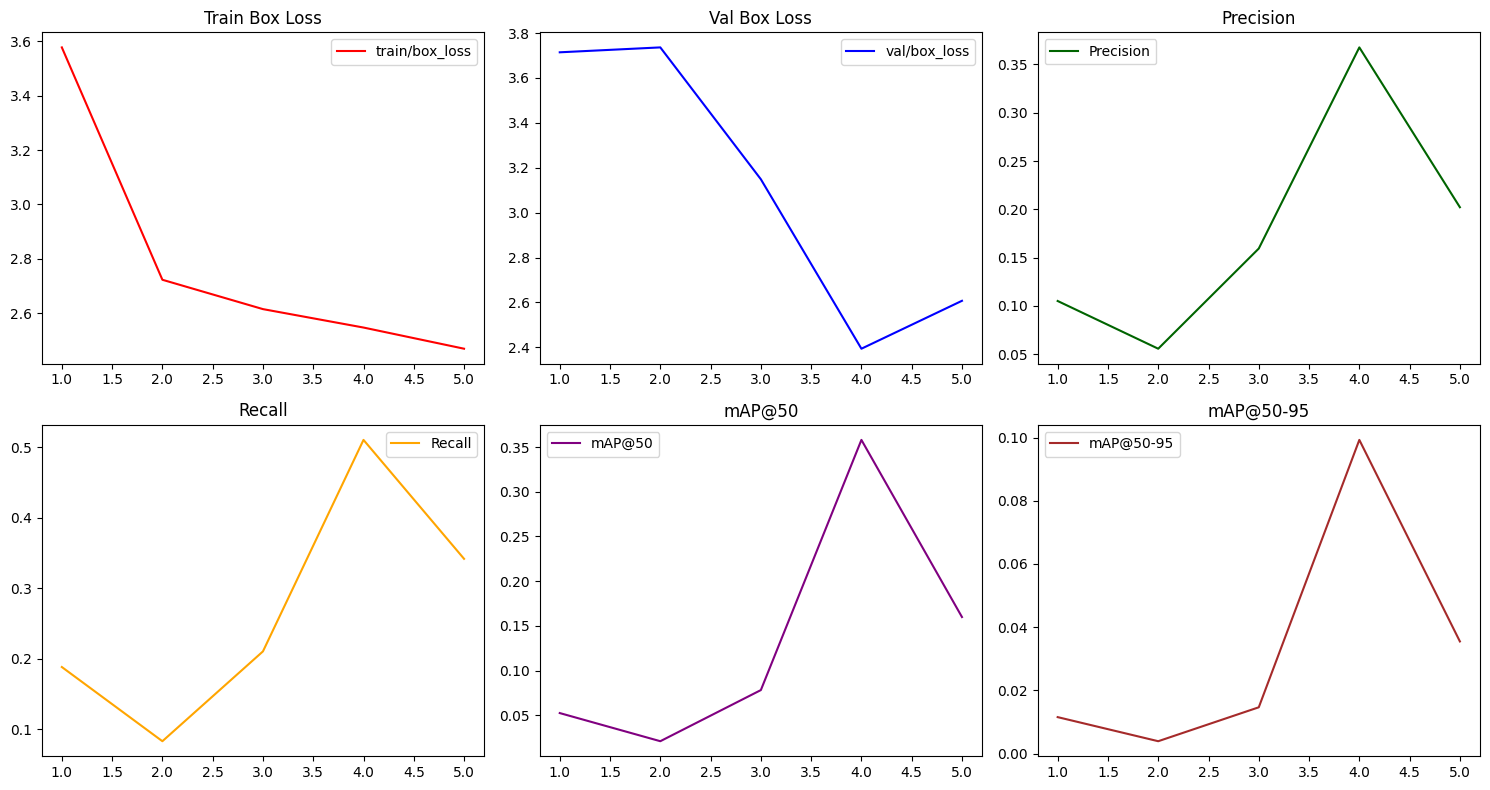

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytujemy csv z wynikami treningu
df = pd.read_csv('runs/train/cane/results.csv')

# Przykładowo odczytujemy epoki
epochs = df['epoch']

# Wybrane kolumny (nazwy mogą minimalnie różnić się w zależności od wersji YOLO)
train_box_loss = df['train/box_loss']
val_box_loss = df['val/box_loss']
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']
map50 = df['metrics/mAP50(B)']
map5095 = df['metrics/mAP50-95(B)']

# Ustawiamy niestandardową kolorystykę (np. tablica kolorów)
# albo domyślnie używamy Seaborn / MPL theme
colors = {
    'train_box_loss': 'red',
    'val_box_loss': 'blue',
    'precision': 'darkgreen',
    'recall': 'orange',
    'map50': 'purple',
    'map5095': 'brown'
}

# Możemy też zmienić domyślny cykl kolorów dla kolejnych linii/wykresów:
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Rysujemy przykładowo parę wykresów obok siebie
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0, 0].plot(epochs, train_box_loss, color=colors['train_box_loss'], label='train/box_loss')
axs[0, 0].legend()
axs[0, 0].set_title("Train Box Loss")

axs[0, 1].plot(epochs, val_box_loss, color=colors['val_box_loss'], label='val/box_loss')
axs[0, 1].legend()
axs[0, 1].set_title("Val Box Loss")

axs[0, 2].plot(epochs, precision, color=colors['precision'], label='Precision')
axs[0, 2].legend()
axs[0, 2].set_title("Precision")

axs[1, 0].plot(epochs, recall, color=colors['recall'], label='Recall')
axs[1, 0].legend()
axs[1, 0].set_title("Recall")

axs[1, 1].plot(epochs, map50, color=colors['map50'], label='mAP@50')
axs[1, 1].legend()
axs[1, 1].set_title("mAP@50")

axs[1, 2].plot(epochs, map5095, color=colors['map5095'], label='mAP@50-95')
axs[1, 2].legend()
axs[1, 2].set_title("mAP@50-95")

plt.tight_layout()
plt.show()  # lub plt.savefig('moj_wykres.png')


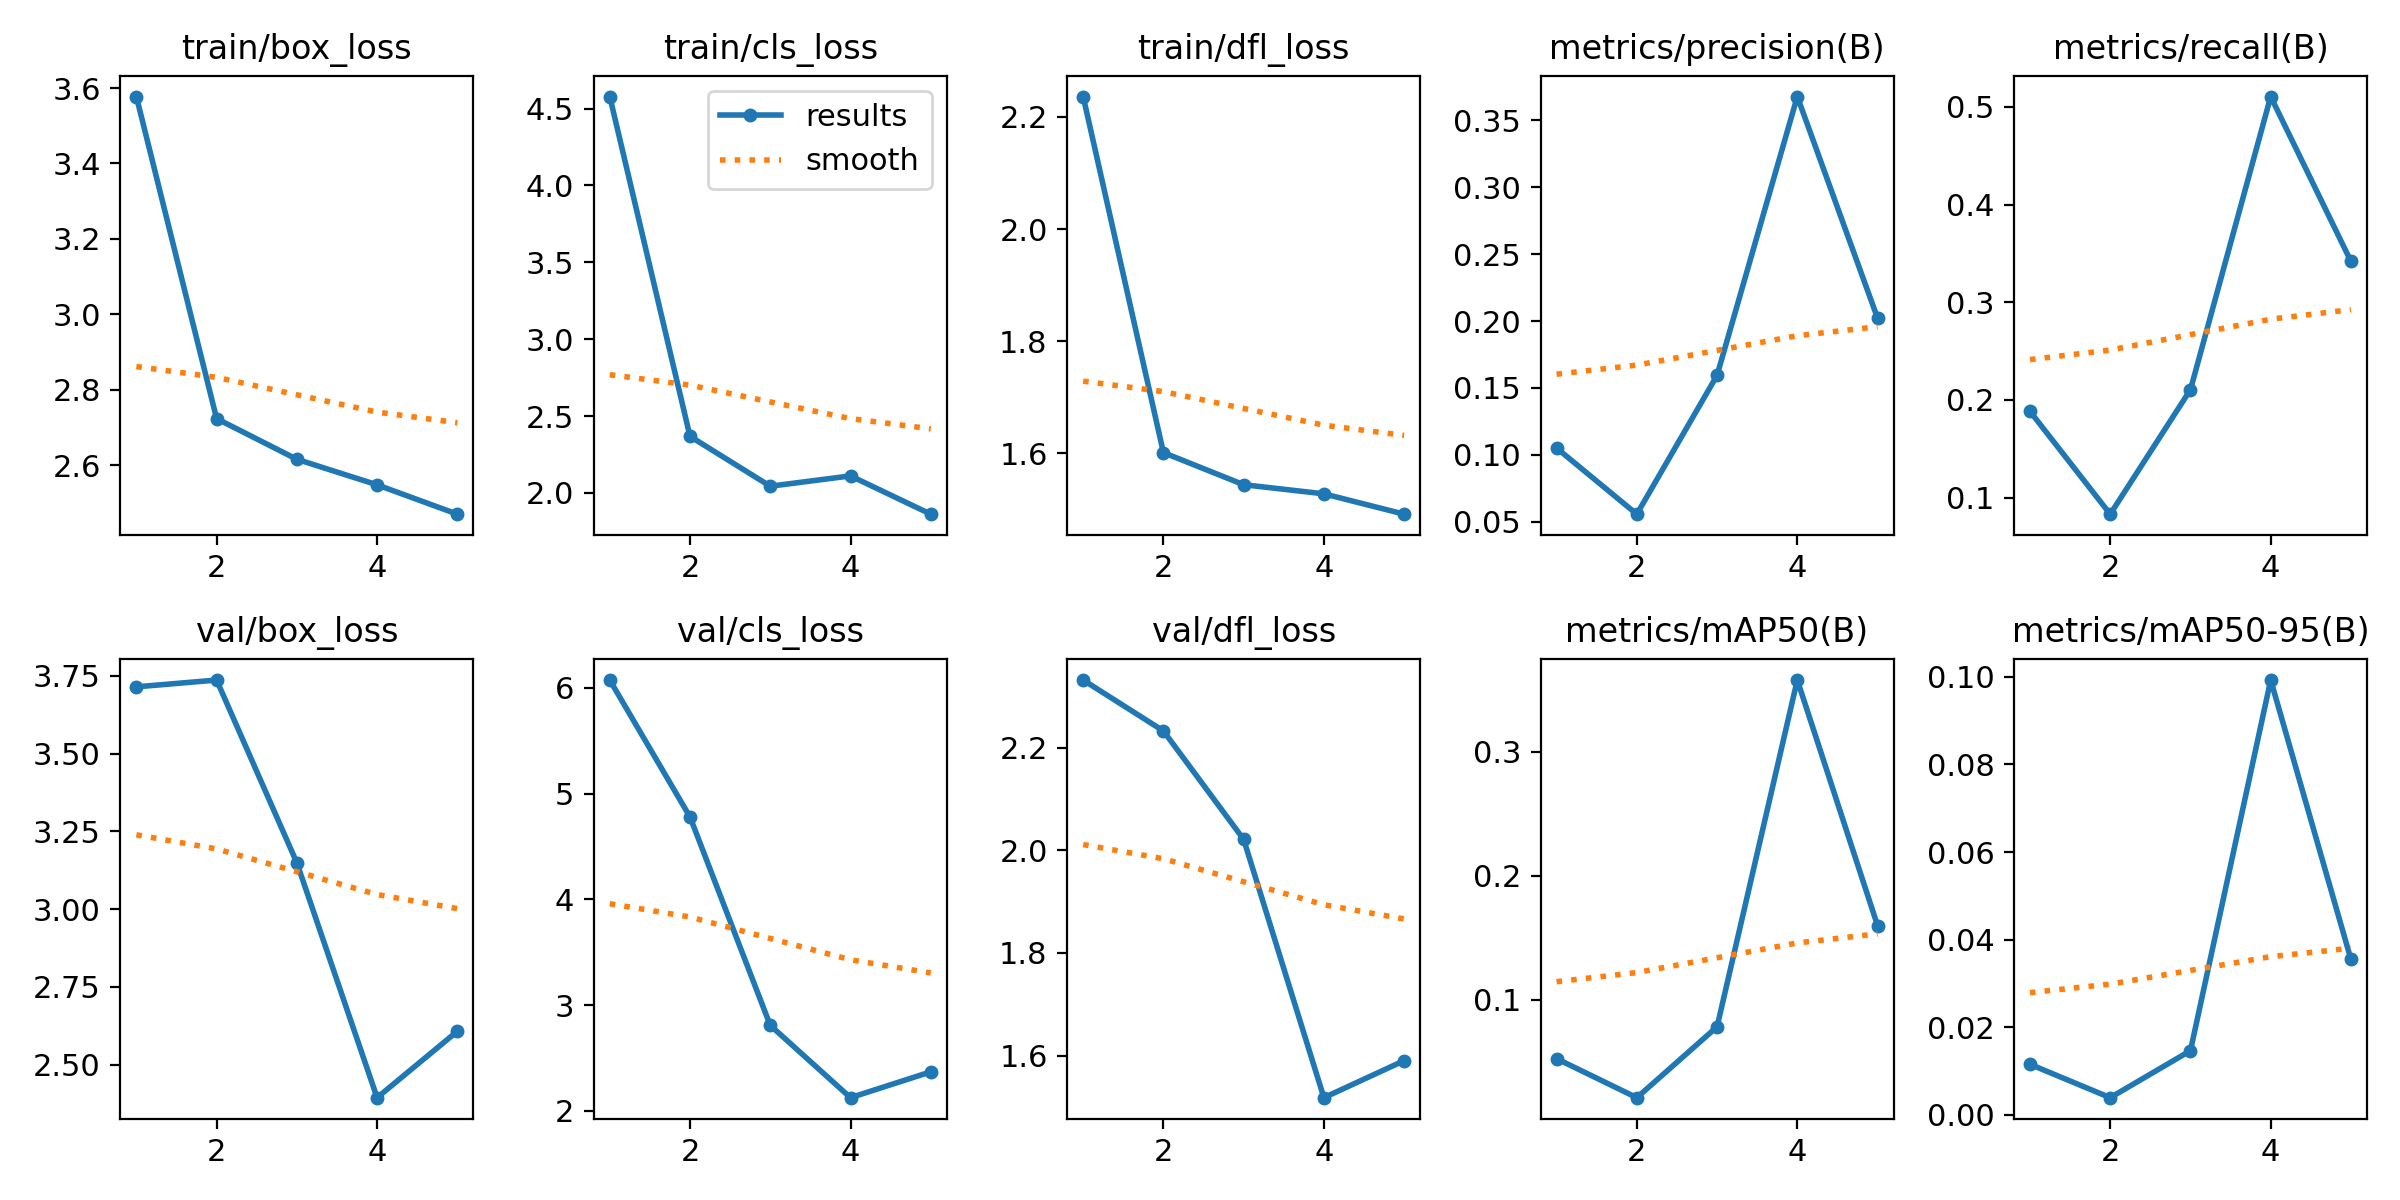

In [ ]:
from IPython.display import Image

# Ścieżka do wygenerowanego wykresu
Image(filename='runs/train/cane/results.png')

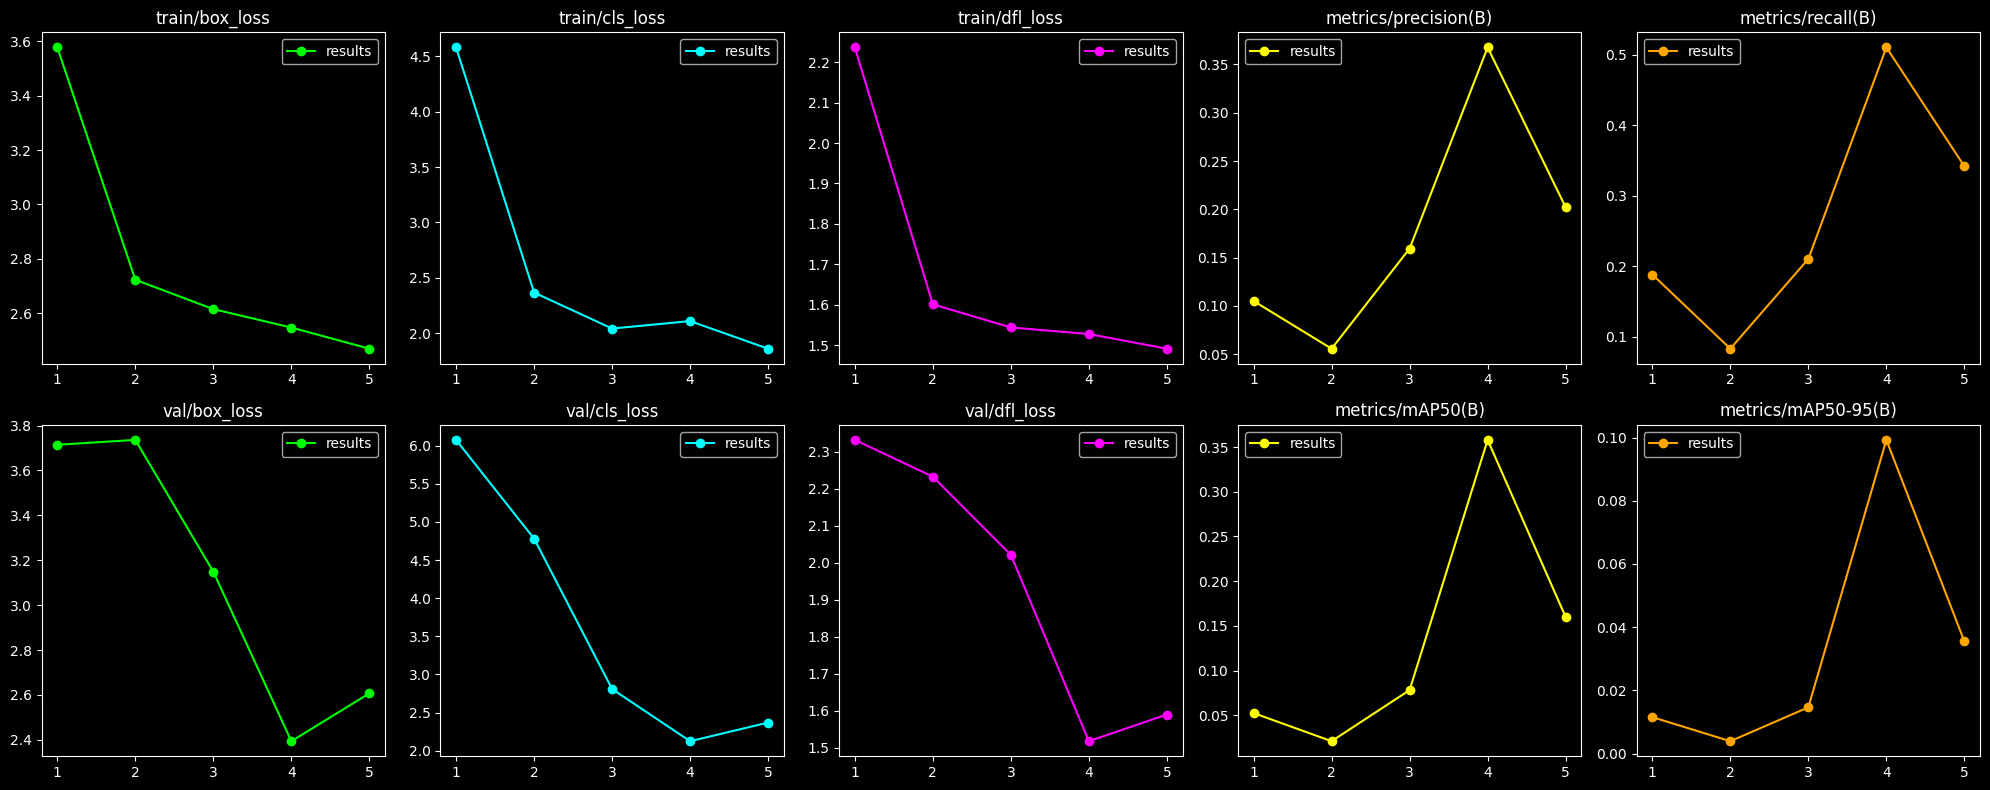

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Opcjonalnie włączamy styl "dark_background" (matplotlib) lub np. styl Seaborn:
plt.style.use("dark_background")
# Możesz też pokombinować z paletą: plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['lime','magenta','cyan','yellow','orange'])

# 2) Wczytujemy wyniki YOLO (domyślnie 'results.csv' w runs/train/ped_train_run/)
df = pd.read_csv('runs/train/cane/results.csv')
epochs = df['epoch']

# 3) Nazwy kolumn mogą się różnić nieco w zależności od wersji YOLO — sprawdź w Twoim pliku CSV
train_box_loss = df['train/box_loss']
train_cls_loss = df['train/cls_loss']
train_dfl_loss = df['train/dfl_loss']
precision       = df['metrics/precision(B)']
recall          = df['metrics/recall(B)']

val_box_loss  = df['val/box_loss']
val_cls_loss  = df['val/cls_loss']
val_dfl_loss  = df['val/dfl_loss']
map50         = df['metrics/mAP50(B)']
map50_95      = df['metrics/mAP50-95(B)']

# 4) Przygotowujemy siatkę 2×5 wykresów
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

# --- Pierwszy rząd (train + precision/recall) ---
# train/box_loss
axs[0, 0].plot(epochs, train_box_loss, color='lime', marker='o', label='results')
axs[0, 0].set_title('train/box_loss')

# train/cls_loss
axs[0, 1].plot(epochs, train_cls_loss, color='cyan', marker='o', label='results')
axs[0, 1].set_title('train/cls_loss')

# train/dfl_loss
axs[0, 2].plot(epochs, train_dfl_loss, color='magenta', marker='o', label='results')
axs[0, 2].set_title('train/dfl_loss')

# metrics/precision(B)
axs[0, 3].plot(epochs, precision, color='yellow', marker='o', label='results')
axs[0, 3].set_title('metrics/precision(B)')

# metrics/recall(B)
axs[0, 4].plot(epochs, recall, color='orange', marker='o', label='results')
axs[0, 4].set_title('metrics/recall(B)')

# --- Drugi rząd (val + mAP) ---
# val/box_loss
axs[1, 0].plot(epochs, val_box_loss, color='lime', marker='o', label='results')
axs[1, 0].set_title('val/box_loss')

# val/cls_loss
axs[1, 1].plot(epochs, val_cls_loss, color='cyan', marker='o', label='results')
axs[1, 1].set_title('val/cls_loss')

# val/dfl_loss
axs[1, 2].plot(epochs, val_dfl_loss, color='magenta', marker='o', label='results')
axs[1, 2].set_title('val/dfl_loss')

# metrics/mAP50(B)
axs[1, 3].plot(epochs, map50, color='yellow', marker='o', label='results')
axs[1, 3].set_title('metrics/mAP50(B)')

# metrics/mAP50-95(B)
axs[1, 4].plot(epochs, map50_95, color='orange', marker='o', label='results')
axs[1, 4].set_title('metrics/mAP50-95(B)')

# 5) Rozsunięcie wykresów, ewentualnie legenda
for ax in axs.flat:
    ax.legend()
plt.tight_layout()

# 6) Wyświetlamy lub zapisujemy do pliku
plt.show()
# plt.savefig("dark_results.png", dpi=300)


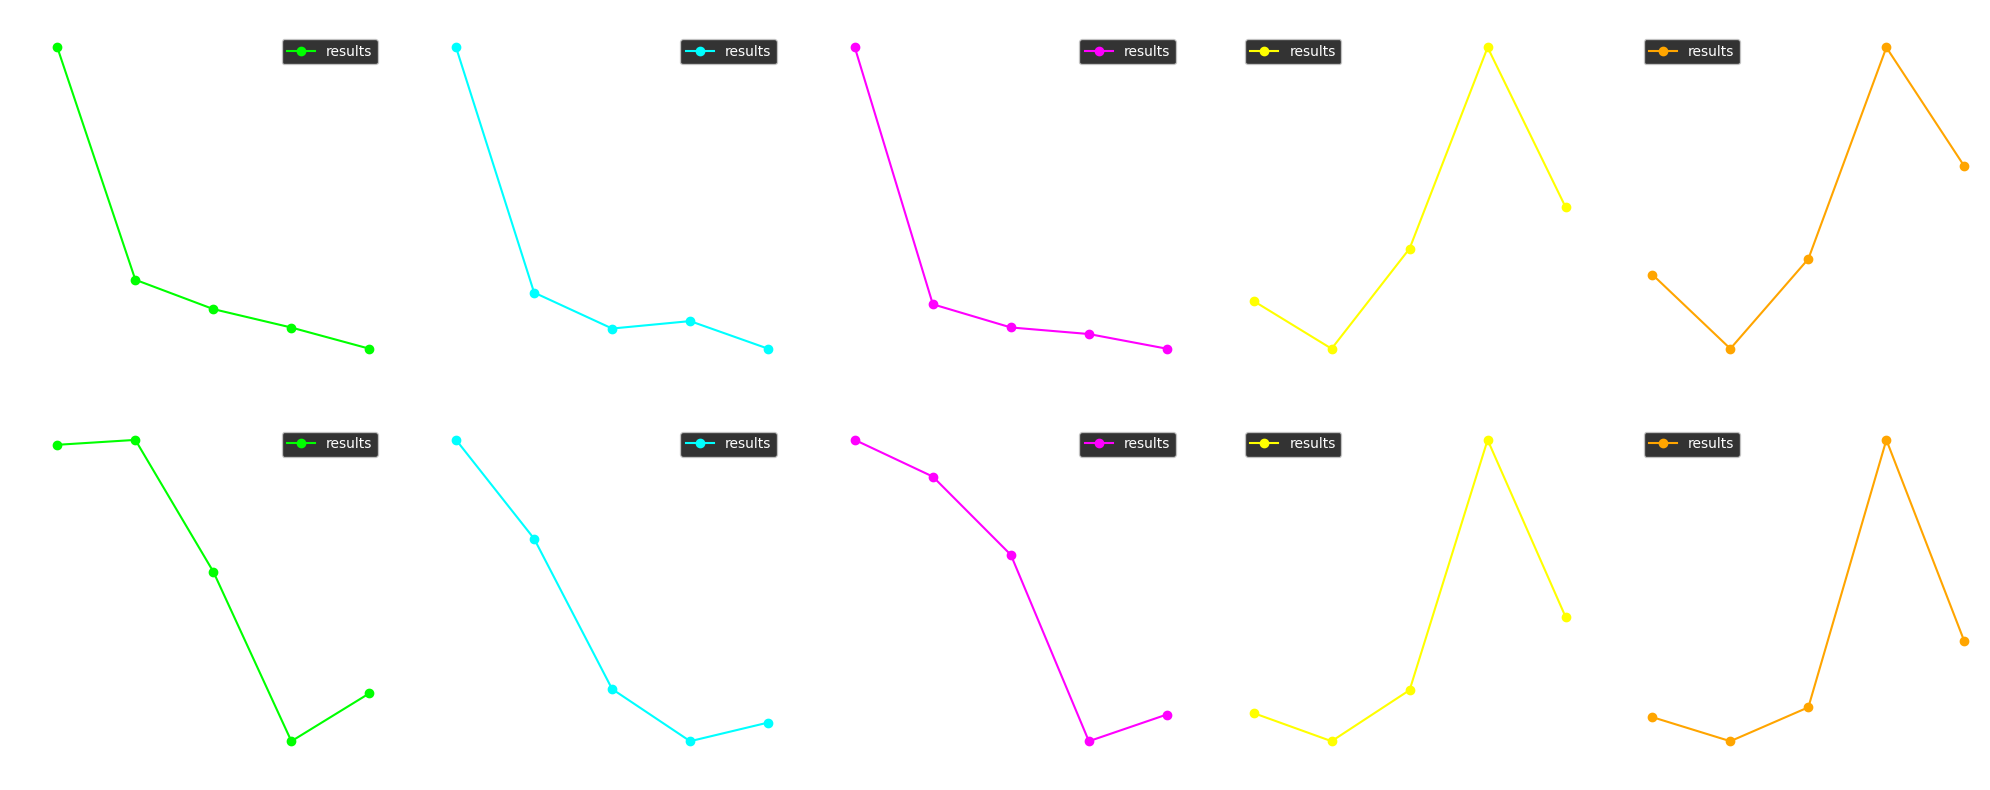

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Na początek możesz wyłączyć styl "dark_background",
#    bo on i tak ustawia tło na czarno. Jeśli jednak chcesz
#    zachować ciemny styl, to wystarczy potem wymusić 'none' w patchach.
# plt.style.use("dark_background")

df = pd.read_csv('runs/train/cane/results.csv')
epochs = df['epoch']

train_box_loss = df['train/box_loss']
train_cls_loss = df['train/cls_loss']
train_dfl_loss = df['train/dfl_loss']
precision      = df['metrics/precision(B)']
recall         = df['metrics/recall(B)']

val_box_loss   = df['val/box_loss']
val_cls_loss   = df['val/cls_loss']
val_dfl_loss   = df['val/dfl_loss']
map50          = df['metrics/mAP50(B)']
map50_95       = df['metrics/mAP50-95(B)']

# 2) Tworzymy figure z facecolor='none'
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor('none')  # Przezroczyste tło figury

# Dla pewności można też ustawić przezroczyste tło dla każdej osi:
for ax in axs.flat:
    ax.set_facecolor('none')

# --- Pierwszy rząd ---
axs[0, 0].plot(epochs, train_box_loss, color='lime', marker='o', label='results')
axs[0, 0].set_title('train/box_loss')
axs[0, 1].plot(epochs, train_cls_loss, color='cyan', marker='o', label='results')
axs[0, 1].set_title('train/cls_loss')
axs[0, 2].plot(epochs, train_dfl_loss, color='magenta', marker='o', label='results')
axs[0, 2].set_title('train/dfl_loss')
axs[0, 3].plot(epochs, precision, color='yellow', marker='o', label='results')
axs[0, 3].set_title('metrics/precision(B)')
axs[0, 4].plot(epochs, recall, color='orange', marker='o', label='results')
axs[0, 4].set_title('metrics/recall(B)')

# --- Drugi rząd ---
axs[1, 0].plot(epochs, val_box_loss, color='lime', marker='o', label='results')
axs[1, 0].set_title('val/box_loss')
axs[1, 1].plot(epochs, val_cls_loss, color='cyan', marker='o', label='results')
axs[1, 1].set_title('val/cls_loss')
axs[1, 2].plot(epochs, val_dfl_loss, color='magenta', marker='o', label='results')
axs[1, 2].set_title('val/dfl_loss')
axs[1, 3].plot(epochs, map50, color='yellow', marker='o', label='results')
axs[1, 3].set_title('metrics/mAP50(B)')
axs[1, 4].plot(epochs, map50_95, color='orange', marker='o', label='results')
axs[1, 4].set_title('metrics/mAP50-95(B)')

# Legenda, layout
for ax in axs.flat:
    ax.legend()
plt.tight_layout()

# 3) Podczas zapisu do png ustawiamy transparent=True
plt.savefig("dark_results_transparent.png", dpi=300, transparent=True)
plt.show()


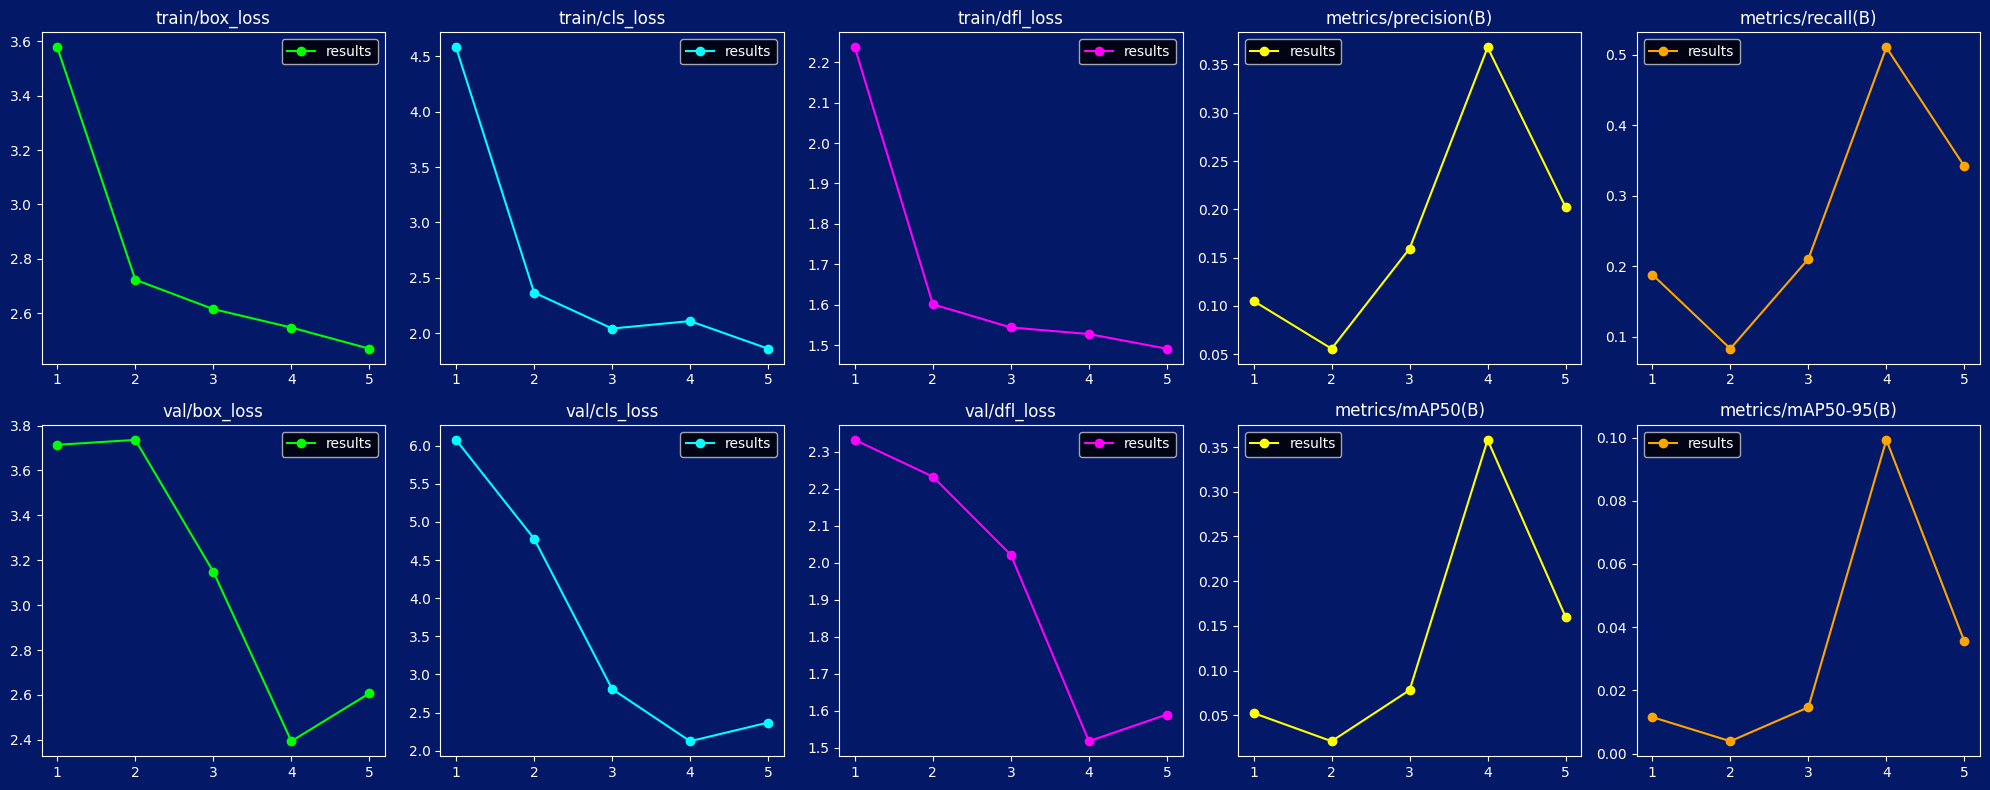

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Możemy zostawić styl "dark_background", aby zachować białe/jaśniejsze opisy
plt.style.use("dark_background")

# Wczytujemy wyniki YOLO (np. 'results.csv' w runs/train/cane/)
df = pd.read_csv('runs/train/cane/results.csv')
epochs = df['epoch']

train_box_loss = df['train/box_loss']
train_cls_loss = df['train/cls_loss']
train_dfl_loss = df['train/dfl_loss']
precision      = df['metrics/precision(B)']
recall         = df['metrics/recall(B)']

val_box_loss   = df['val/box_loss']
val_cls_loss   = df['val/cls_loss']
val_dfl_loss   = df['val/dfl_loss']
map50          = df['metrics/mAP50(B)']
map50_95       = df['metrics/mAP50-95(B)']

# 2) Tworzymy figurę i podploty
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

# Ustawiamy kolor tła figury
fig.patch.set_facecolor('#031867')

# Ustawiamy kolor tła poszczególnych osi
for ax in axs.flat:
    ax.set_facecolor('#031867')

# --- Pierwszy rząd (train + precision/recall) ---
axs[0, 0].plot(epochs, train_box_loss, color='lime', marker='o', label='results')
axs[0, 0].set_title('train/box_loss')

axs[0, 1].plot(epochs, train_cls_loss, color='cyan', marker='o', label='results')
axs[0, 1].set_title('train/cls_loss')

axs[0, 2].plot(epochs, train_dfl_loss, color='magenta', marker='o', label='results')
axs[0, 2].set_title('train/dfl_loss')

axs[0, 3].plot(epochs, precision, color='yellow', marker='o', label='results')
axs[0, 3].set_title('metrics/precision(B)')

axs[0, 4].plot(epochs, recall, color='orange', marker='o', label='results')
axs[0, 4].set_title('metrics/recall(B)')

# --- Drugi rząd (val + mAP) ---
axs[1, 0].plot(epochs, val_box_loss, color='lime', marker='o', label='results')
axs[1, 0].set_title('val/box_loss')

axs[1, 1].plot(epochs, val_cls_loss, color='cyan', marker='o', label='results')
axs[1, 1].set_title('val/cls_loss')

axs[1, 2].plot(epochs, val_dfl_loss, color='magenta', marker='o', label='results')
axs[1, 2].set_title('val/dfl_loss')

axs[1, 3].plot(epochs, map50, color='yellow', marker='o', label='results')
axs[1, 3].set_title('metrics/mAP50(B)')

axs[1, 4].plot(epochs, map50_95, color='orange', marker='o', label='results')
axs[1, 4].set_title('metrics/mAP50-95(B)')

# Legenda, layout
for ax in axs.flat:
    ax.legend()

plt.tight_layout()

# 3) Zapisujemy do pliku (tło będzie #031867, a nie przezroczyste)
plt.savefig("dark_results_blue.png", dpi=300)
plt.show()


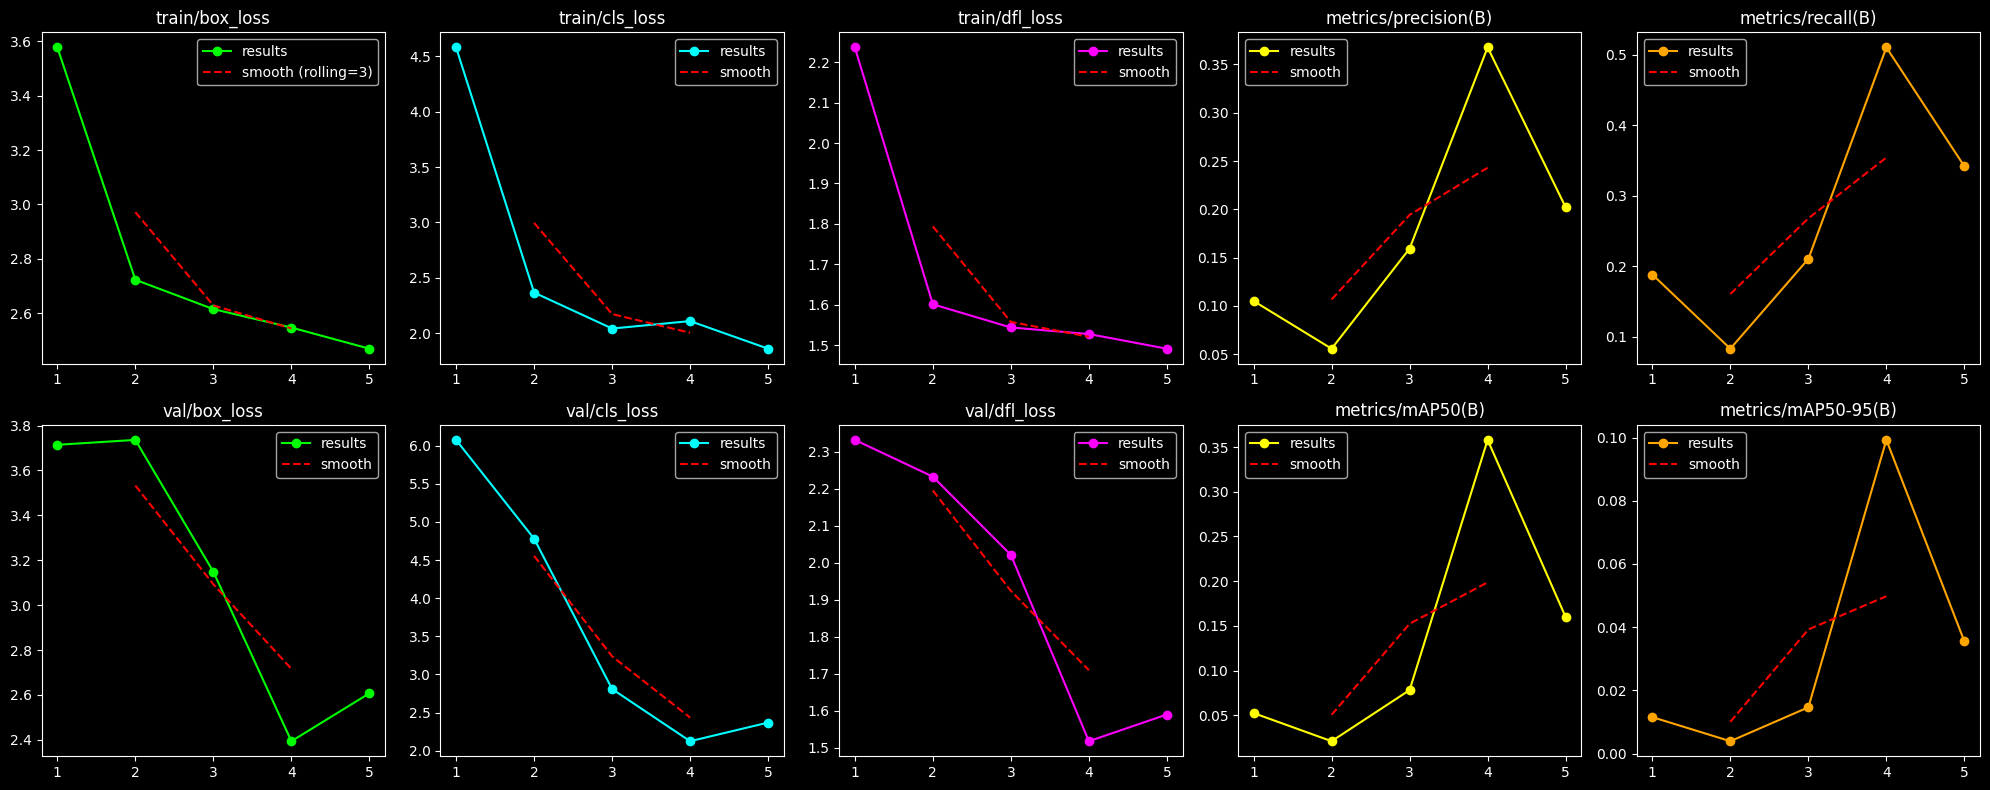

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Styl "dark_background" (matplotlib) lub np. Seaborn
plt.style.use("dark_background")

# 2) Wczytujemy wyniki YOLO (np. 'results.csv' z runs/train/ped_train_run/)
df = pd.read_csv('runs/train/cane/results.csv')
epochs = df['epoch']

# 3) Przykładowe kolumny (dopasuj do swoich nazwy)
train_box_loss = df['train/box_loss']
train_cls_loss = df['train/cls_loss']
train_dfl_loss = df['train/dfl_loss']
precision      = df['metrics/precision(B)']
recall         = df['metrics/recall(B)']

val_box_loss   = df['val/box_loss']
val_cls_loss   = df['val/cls_loss']
val_dfl_loss   = df['val/dfl_loss']
map50          = df['metrics/mAP50(B)']
map50_95       = df['metrics/mAP50-95(B)']

# 4) Przygotowujemy siatkę 2×5 wykresów
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

# --- Przykład, jak dodać linię "smooth" dla train_box_loss ---
# 1) Rysujemy oryginalne wartości
axs[0, 0].plot(epochs, train_box_loss, color='lime', marker='o', label='results')

# 2) Tworzymy wygładzoną krzywą metodą rolling (np. 3 punkty, center=True)
train_box_loss_smooth = train_box_loss.rolling(window=3, center=True).mean()
axs[0, 0].plot(epochs, train_box_loss_smooth, color='red', linestyle='--',
               label='smooth (rolling=3)')

axs[0, 0].set_title('train/box_loss')
axs[0, 0].legend()

# --- Analogicznie dla pozostałych wykresów ---
# train/cls_loss
axs[0, 1].plot(epochs, train_cls_loss, color='cyan', marker='o', label='results')
train_cls_loss_smooth = train_cls_loss.rolling(window=3, center=True).mean()
axs[0, 1].plot(epochs, train_cls_loss_smooth, color='red', linestyle='--', label='smooth')
axs[0, 1].set_title('train/cls_loss')
axs[0, 1].legend()

# train/dfl_loss
axs[0, 2].plot(epochs, train_dfl_loss, color='magenta', marker='o', label='results')
train_dfl_loss_smooth = train_dfl_loss.rolling(window=3, center=True).mean()
axs[0, 2].plot(epochs, train_dfl_loss_smooth, color='red', linestyle='--', label='smooth')
axs[0, 2].set_title('train/dfl_loss')
axs[0, 2].legend()

# metrics/precision(B)
axs[0, 3].plot(epochs, precision, color='yellow', marker='o', label='results')
precision_smooth = precision.rolling(window=3, center=True).mean()
axs[0, 3].plot(epochs, precision_smooth, color='red', linestyle='--', label='smooth')
axs[0, 3].set_title('metrics/precision(B)')
axs[0, 3].legend()

# metrics/recall(B)
axs[0, 4].plot(epochs, recall, color='orange', marker='o', label='results')
recall_smooth = recall.rolling(window=3, center=True).mean()
axs[0, 4].plot(epochs, recall_smooth, color='red', linestyle='--', label='smooth')
axs[0, 4].set_title('metrics/recall(B)')
axs[0, 4].legend()

# --- Drugi rząd (val + mAP) ---
# val/box_loss
axs[1, 0].plot(epochs, val_box_loss, color='lime', marker='o', label='results')
val_box_loss_smooth = val_box_loss.rolling(window=3, center=True).mean()
axs[1, 0].plot(epochs, val_box_loss_smooth, color='red', linestyle='--', label='smooth')
axs[1, 0].set_title('val/box_loss')
axs[1, 0].legend()

# val/cls_loss
axs[1, 1].plot(epochs, val_cls_loss, color='cyan', marker='o', label='results')
val_cls_loss_smooth = val_cls_loss.rolling(window=3, center=True).mean()
axs[1, 1].plot(epochs, val_cls_loss_smooth, color='red', linestyle='--', label='smooth')
axs[1, 1].set_title('val/cls_loss')
axs[1, 1].legend()

# val/dfl_loss
axs[1, 2].plot(epochs, val_dfl_loss, color='magenta', marker='o', label='results')
val_dfl_loss_smooth = val_dfl_loss.rolling(window=3, center=True).mean()
axs[1, 2].plot(epochs, val_dfl_loss_smooth, color='red', linestyle='--', label='smooth')
axs[1, 2].set_title('val/dfl_loss')
axs[1, 2].legend()

# metrics/mAP50(B)
axs[1, 3].plot(epochs, map50, color='yellow', marker='o', label='results')
map50_smooth = map50.rolling(window=3, center=True).mean()
axs[1, 3].plot(epochs, map50_smooth, color='red', linestyle='--', label='smooth')
axs[1, 3].set_title('metrics/mAP50(B)')
axs[1, 3].legend()

# metrics/mAP50-95(B)
axs[1, 4].plot(epochs, map50_95, color='orange', marker='o', label='results')
map50_95_smooth = map50_95.rolling(window=3, center=True).mean()
axs[1, 4].plot(epochs, map50_95_smooth, color='red', linestyle='--', label='smooth')
axs[1, 4].set_title('metrics/mAP50-95(B)')
axs[1, 4].legend()

# 5) Rozsunięcie wykresów, ewentualnie legenda
plt.tight_layout()

# 6) Wyświetlamy lub zapisujemy do pliku
plt.show()
# plt.savefig("dark_results_with_smooth.png", dpi=300)


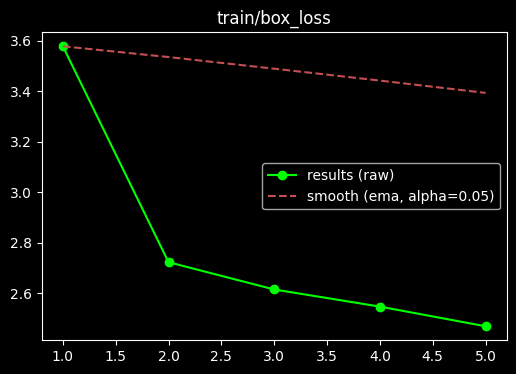

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Funkcja "ema_smooth" zbliżona do tego, co było (i bywa) w YOLO
def ema_smooth(values, alpha=0.05):
    """
    Exponential Moving Average smoothing.
    alpha=0.05 oznacza, że 5% "nowej" wartości jest dodawane do 95% poprzedniej wartości.
    """
    smoothed = [values[0]]  # Zaczynamy od pierwszego punktu
    for v in values[1:]:
        smoothed.append(smoothed[-1] * (1 - alpha) + v * alpha)
    return smoothed

# 1) Styl "dark_background" (opcjonalnie)
plt.style.use("dark_background")

# 2) Wczytujemy wyniki YOLO (np. 'results.csv' w runs/train/ped_train_run/)
df = pd.read_csv('runs/train/cane/results.csv')

epochs = df['epoch']

# Przykładowe kolumny (dopasuj do nazewnictwa w Twoim pliku)
train_box_loss = df['train/box_loss']
train_cls_loss = df['train/cls_loss']
precision      = df['metrics/precision(B)']
recall         = df['metrics/recall(B)']

# 3) Wykres train_box_loss z surową i wygładzoną linią
plt.figure(figsize=(6,4))
plt.plot(epochs, train_box_loss, 'o-', color='lime', label='results (raw)')

train_box_loss_smooth = ema_smooth(train_box_loss, alpha=0.05)
plt.plot(epochs, train_box_loss_smooth, 'r--', label='smooth (ema, alpha=0.05)')

plt.title('train/box_loss')
plt.legend()
plt.show()
